In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import os

In [ ]:
def load_dataset(base_path):
    data = {}

    for channel in ["DE", "FE"]:
        data[channel] = {}

        for cls in ["B", "IR", "OR"]:
            path = os.path.join(base_path, channel, cls)

            signals = []

            for file in os.listdir(path):
                if not file.endswith(".mat"):
                    continue

                mat = sio.loadmat(os.path.join(path, file))

                # ищем любой ключ с time
                signal = None
                for k in mat.keys():
                    if "time" in k.lower():
                        signal = np.asarray(mat[k]).squeeze()
                        break

                if signal is not None:
                    signals.append(signal)

            data[channel][cls] = signals

    return data

In [46]:
data12k = load_dataset("Data/12K/")

In [ ]:
print("Загрузка завершена")
print("DE/B:", len(data12k["DE"]["B"]))
print("DE/IR:", len(data12k["DE"]["IR"]))
print("DE/OR:", len(data12k["DE"]["OR"]))

Загрузка завершена
DE/B: 16
DE/IR: 16
DE/OR: 28


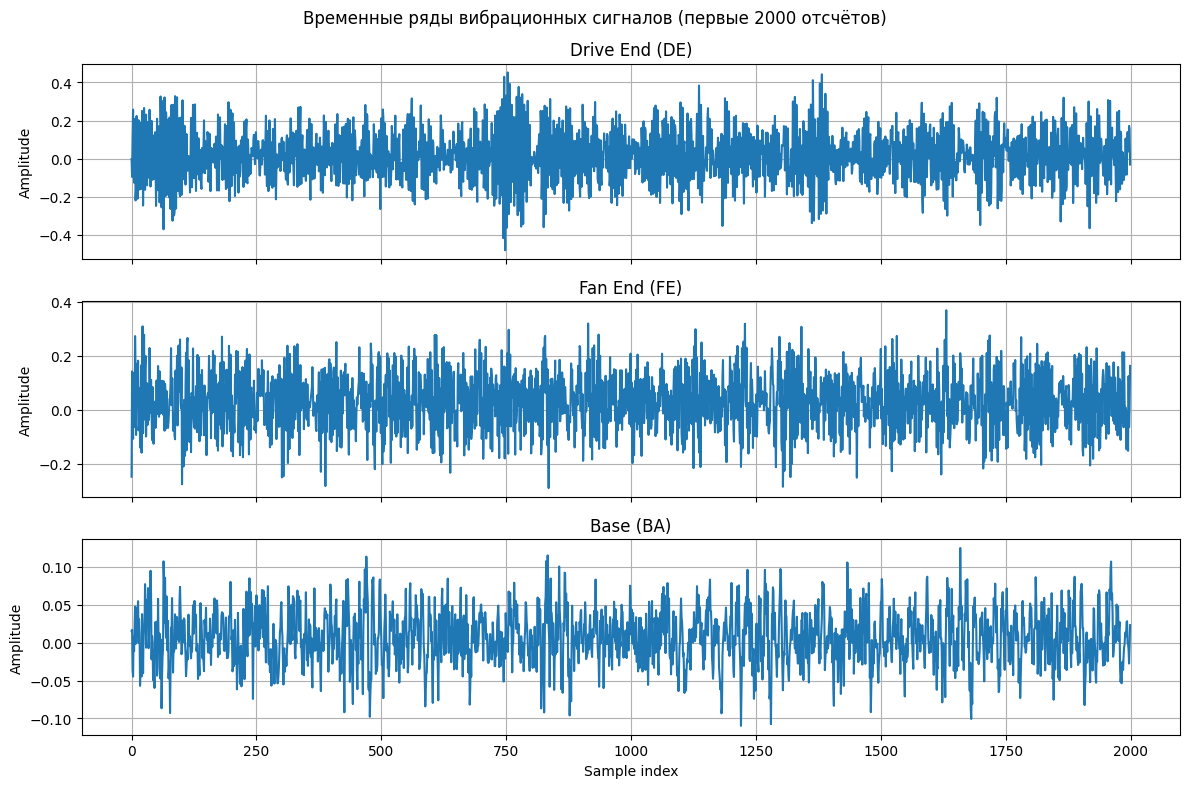

In [25]:
# предполагаем, что уже есть:
# de, fe, ba

# берём кусок сигнала (иначе будет каша)
N = 2000

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# DE
axs[0].plot(de[:N])
axs[0].set_title('Drive End (DE)')
axs[0].set_ylabel('Amplitude')
axs[0].grid()

# FE
axs[1].plot(fe[:N])
axs[1].set_title('Fan End (FE)')
axs[1].set_ylabel('Amplitude')
axs[1].grid()

# BA
axs[2].plot(ba[:N])
axs[2].set_title('Base (BA)')
axs[2].set_xlabel('Sample index')
axs[2].set_ylabel('Amplitude')
axs[2].grid()

plt.suptitle('Временные ряды вибрационных сигналов (первые 2000 отсчётов)')
plt.tight_layout()
plt.savefig("./PlotDEFEBA.jpg")
plt.show()

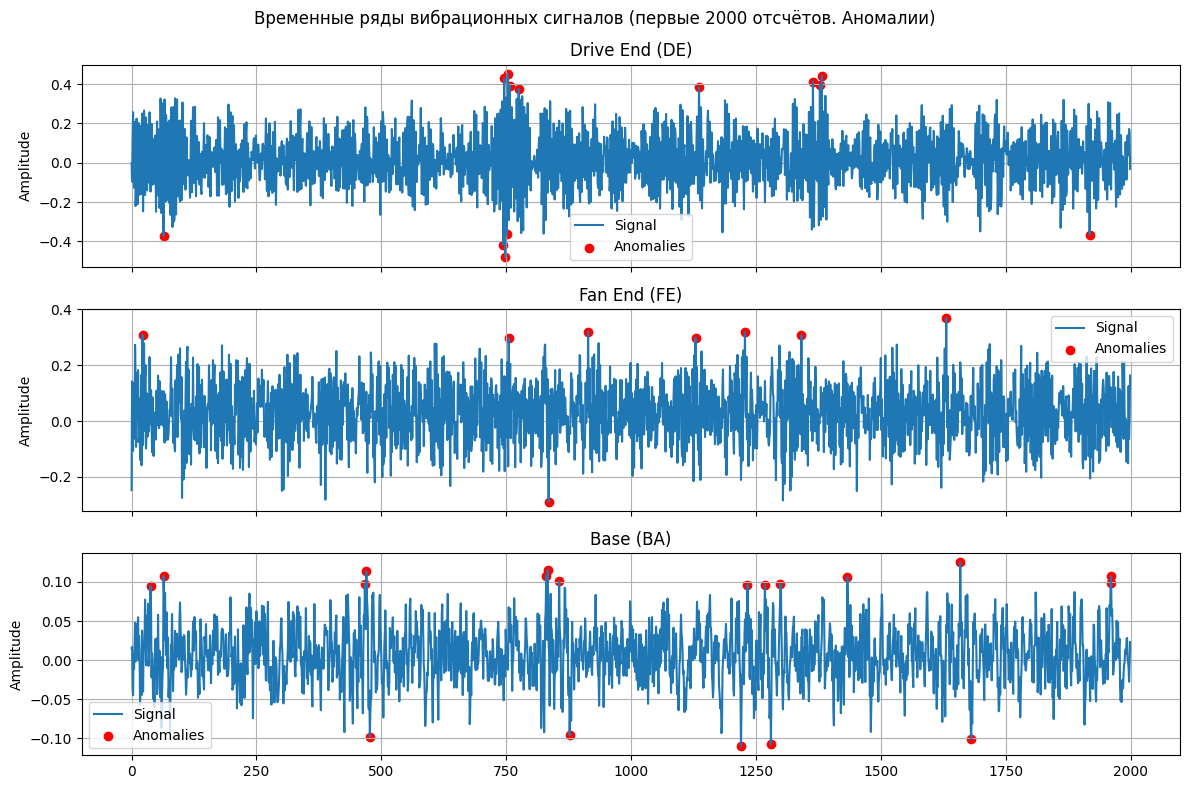

In [ ]:
# Приводим сигналы к 1D
signalDe = np.asarray(de).squeeze().astype(float)
signalFe = np.asarray(fe).squeeze().astype(float)
signalBa = np.asarray(ba).squeeze().astype(float)

# порог по модулю сигнала
def calc_threshold(signal, k=3):
    abs_signal = np.abs(signal)
    return np.mean(abs_signal) + k * np.std(abs_signal)

thresholdOne = calc_threshold(signalDe)
thresholdTwo = calc_threshold(signalFe)
thresholdThree = calc_threshold(signalBa)

# находим аномалии
anomaliesOne = np.abs(signalDe) > thresholdOne
anomaliesTwo = np.abs(signalFe) > thresholdTwo
anomaliesThree = np.abs(signalBa) > thresholdThree

# график
N = 2000
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(signalDe[:N], label='Signal')
axs[0].scatter(
    np.where(anomaliesOne[:N])[0],
    signalDe[:N][anomaliesOne[:N]],
    color='red',
    label='Anomalies'
)
axs[0].set_title('Drive End (DE)')
axs[0].set_ylabel('Amplitude')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(signalFe[:N], label='Signal')
axs[1].scatter(
    np.where(anomaliesTwo[:N])[0],
    signalFe[:N][anomaliesTwo[:N]],
    color='red',
    label='Anomalies'
)
axs[1].set_title('Fan End (FE)')
axs[1].set_ylabel('Amplitude')
axs[1].legend()
axs[1].grid(True)

axs[2].plot(signalBa[:N], label='Signal')
axs[2].scatter(
    np.where(anomaliesThree[:N])[0],
    signalBa[:N][anomaliesThree[:N]],
    color='red',
    label='Anomalies'
)
axs[2].set_title('Base (BA)')
axs[2].set_ylabel('Amplitude')
axs[2].legend()
axs[2].grid(True)

plt.suptitle('Временные ряды вибрационных сигналов (первые 2000 отсчётов. Аномалии)')
plt.tight_layout()
plt.savefig("./PlotDEFEBA.jpg")
plt.show()

In [37]:

# ---------- загрузка ----------
mat = scipy.io.loadmat('Data/Normal/Normal_0.mat')


# ---------- функция статистики ----------
def stats(x):
    return {
        "count": len(x),
        "mean": np.mean(x),
        "std": np.std(x),
        "min": np.min(x),
        "Q1": np.percentile(x, 25),
        "median": np.median(x),
        "Q3": np.percentile(x, 75),
        "max": np.max(x),
    }

# ---------- считаем ----------
df_stats = pd.DataFrame({
    "DE": stats(de),
    "FE": stats(fe),
    "BA": stats(ba),
})

# транспонируем для красивого вида
df_stats = df_stats

print("\n=== STATISTICAL SUMMARY ===\n")
print(df_stats)


=== STATISTICAL SUMMARY ===

                   DE             FE             BA
count   243938.000000  243938.000000  122571.000000
mean         0.012558       0.031376       0.005554
std          0.072687       0.078645       0.035377
min         -0.286638      -0.246135      -0.154391
Q1          -0.037551      -0.025065      -0.018187
median       0.012517       0.029175       0.005352
Q3           0.063628       0.085880       0.029132
max          0.311254       0.357491       0.161231
